In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

In [14]:
data = pd.read_csv('../M1_final.csv')

In [15]:
# Drop unnecessary features
data.drop(columns=['TAIL_NUM'], inplace=True)

# create target variable
data['is_delayed'] = np.where(
    data['DEP_DELAY'] >= 15,
    1,
    0
)
data.drop(columns=['DEP_DELAY'], inplace=True)

# Drop null rows
data.dropna(inplace=True)

## Feature engineering

In [16]:
def get_time_of_day(minutes):
    if 300 <= minutes < 720:        # 5:00am - 11:59am
        return 'Morning'
    elif 720 <= minutes < 1020:     # 12:00pm - 4:59pm
        return 'Afternoon'
    elif 1020 <= minutes < 1260:    # 5:00pm - 8:59pm
        return 'Evening'
    else:                           # 9:00pm - 4:59am
        return 'Night'
    

# data['time_of_day'] = data['CRS_DEP_M'].apply(get_time_of_day)


### Temporal lag feature

In [17]:
# Function to create temporal features
def create_temporal_features(df):

    df = df.copy()
    
    # Create a new date_order column to sort data according to date time
    df['date_order'] = df['MONTH'] * 100 + df['DAY_OF_MONTH']
    
    # Sort by destination, date, then departure time
    df = df.sort_values(["DEST", "date_order", "CRS_DEP_M"])
    
    # Previous flight delay at same destination
    df["prev_delay"] = df.groupby("DEST")["is_delayed"].shift(1)
    
    # Rolling delay rate over last 3 flights at same destination
    df["rolling_delay_rate_3"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Rolling delay rate over last 5 flights at same destination
    df["rolling_delay_rate_5"] = (
        df.groupby("DEST")["is_delayed"]
        .rolling(5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    
    # Fill NaN values from the shift operation
    df["prev_delay"] = df["prev_delay"].fillna(0)
    
    # Drop temporary date_order column
    df = df.drop('date_order', axis=1)
    
    return df

## Stratified train test split

In [18]:
# Stratified Train test split
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
['is_delayed']
for train_index, test_index in splitter.split(data, data['is_delayed']):
    # Split the data first
    train_data = data.iloc[train_index].copy()
    test_data = data.iloc[test_index].copy()
    
    # Apply temporal features separately to avoid leakage
    train_data = create_temporal_features(train_data)
    test_data = create_temporal_features(test_data)
    
    # Now split into X and y
    x_train = train_data.drop('is_delayed', axis=1)
    y_train = train_data['is_delayed']
    x_test = test_data.drop('is_delayed', axis=1)
    y_test = test_data['is_delayed']

## Transformers

In [19]:
class WindDirectionTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Wind'):
        self.column = column
        self.wind_dict = {
            'NNW': 340, 'CALM': 0, 'NNE': 20, 'NE': 45, 'VAR': 0, 'WSW': 230, 
            'S': 180, 'SSW': 200, 'WNW': 290, 'ESE': 115, 'N': 360, 'SW': 225, 
            'E': 90, 'W': 270, 'SSE': 155, 'ENE': 70, 'NW': 315, 'SE': 135
        }

    def fit(self, X, y=None):
        return self
    

    def transform(self, X):
        X = X.copy()
        # Map wind directions to degrees
        X['wind_deg'] = X[self.column].map(self.wind_dict)
        # Convert to radians
        X['wind_rad'] = np.deg2rad(X['wind_deg'])
        #Compute sin and cos
        X['wind_sin'] = np.sin(X['wind_rad'])
        X['wind_cos'] = np.cos(X['wind_rad'])
        # Drop original columns
        X = X.drop(columns=[self.column, 'wind_deg', 'wind_rad'])
        return X

In [20]:
class DewPointTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='Dew Point'):
        self.column = column
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # Clean column
        X[self.column] = (
            X[self.column].astype(str).str.replace('\xa0', '', regex=False).str.strip()
        )
        # Convert them into numeric values
        X[self.column] = pd.to_numeric(X[self.column], errors='coerce')

        return X

In [21]:
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('Wind transformer', WindDirectionTransformer(column='Wind'), ['Wind']),
    ('Dew Point Transformer', DewPointTransformer(column='Dew Point'), ['Dew Point']),
    ('OrdinalEncoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['DEST', 'OP_UNIQUE_CARRIER', 'Condition'])
], remainder='passthrough')

## Create Initial Pipeline

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Create initial Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1
)

# Create pipeline
pipe = Pipeline([
    ('Preprocessor', preprocessor),
    ('DT', dt_model)
])

print("✓ Initial pipeline created")
print("\nPipeline steps:")
for step_name, step in pipe.steps:
    print(f"  {step_name}: {step.__class__.__name__}")

✓ Initial pipeline created

Pipeline steps:
  Preprocessor: ColumnTransformer
  DT: DecisionTreeClassifier


## Optuna Hyperparameter Optimization

Finding the best hyperparameters for Decision Tree with temporal lag features:

In [23]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import warnings

# Suppress warnings and Optuna's default logging to get clean progress bar
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.ERROR)

def objective(trial):
    # Define hyperparameter search space EXACTLY matching decisionTreeLeakage.ipynb GridSearchCV
    params = {
        # Match the exact parameter grid from decisionTreeLeakage.ipynb
        'DT__criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'DT__max_depth': trial.suggest_categorical('max_depth', [5, 7, 10, 15]),
        'DT__min_samples_leaf': trial.suggest_categorical('min_samples_leaf', [15, 20, 25]),
        'DT__min_samples_split': trial.suggest_categorical('min_samples_split', [20, 40, 60]),
        'DT__max_features': trial.suggest_categorical('max_features', [None, 'sqrt', 'log2']),
        'DT__class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])
    }
    
    # Set parameters to the pipeline
    pipe.set_params(**params)
    
    # Perform cross-validation
    # Using accuracy as the metric, same as GridSearchCV
    cv_scores = cross_val_score(
        pipe, 
        x_train, 
        y_train, 
        cv=5,  # Same as GridSearchCV
        scoring='accuracy',
        n_jobs=1  # Single job to ensure proper progress display
    )
    
    # Return mean accuracy
    return cv_scores.mean()

In [24]:
# Calculate total possible combinations for GridSearchCV equivalence
# criterion: 2 options, max_depth: 4 options, min_samples_leaf: 3 options
# min_samples_split: 3 options, max_features: 3 options, class_weight: 2 options
total_combinations = 2 * 4 * 3 * 3 * 3 * 2  # = 432 combinations

print(f"GridSearchCV would test {total_combinations} combinations")
print("Setting Optuna trials to cover all combinations...")

# Define the search space for GridSampler
search_space = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 7, 10, 15],
    'min_samples_leaf': [15, 20, 25],
    'min_samples_split': [20, 40, 60],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

# Create Optuna study to match GridSearchCV behavior
study = optuna.create_study(
    direction='maximize',  # Maximize accuracy
    study_name='DecisionTree_GridSearch_Equivalent',
    sampler=optuna.samplers.GridSampler(search_space)  # Use grid sampling like GridSearchCV
)

# Run optimization to cover all parameter combinations
study.optimize(objective, n_trials=total_combinations, show_progress_bar=True, n_jobs=1)

print("\n" + "="*60)
print("Optimization Complete!")
print(f"Tested all {total_combinations} parameter combinations!")
print("="*60)

GridSearchCV would test 432 combinations
Setting Optuna trials to cover all combinations...


Best trial: 111. Best value: 0.944527: 100%|██████████| 432/432 [03:46<00:00,  1.91it/s]


Optimization Complete!
Tested all 432 parameter combinations!


In [25]:
# Display best parameters
print("Best Trial:")
print(f"  Value (Accuracy): {study.best_trial.value:.4f} ({100 * study.best_trial.value:.2f}%)")
print(f"  Number: {study.best_trial.number}")
print("\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best Trial:
  Value (Accuracy): 0.9445 (94.45%)
  Number: 111

Best Hyperparameters:
  criterion: gini
  max_depth: 15
  min_samples_leaf: 15
  min_samples_split: 20
  max_features: None
  class_weight: None


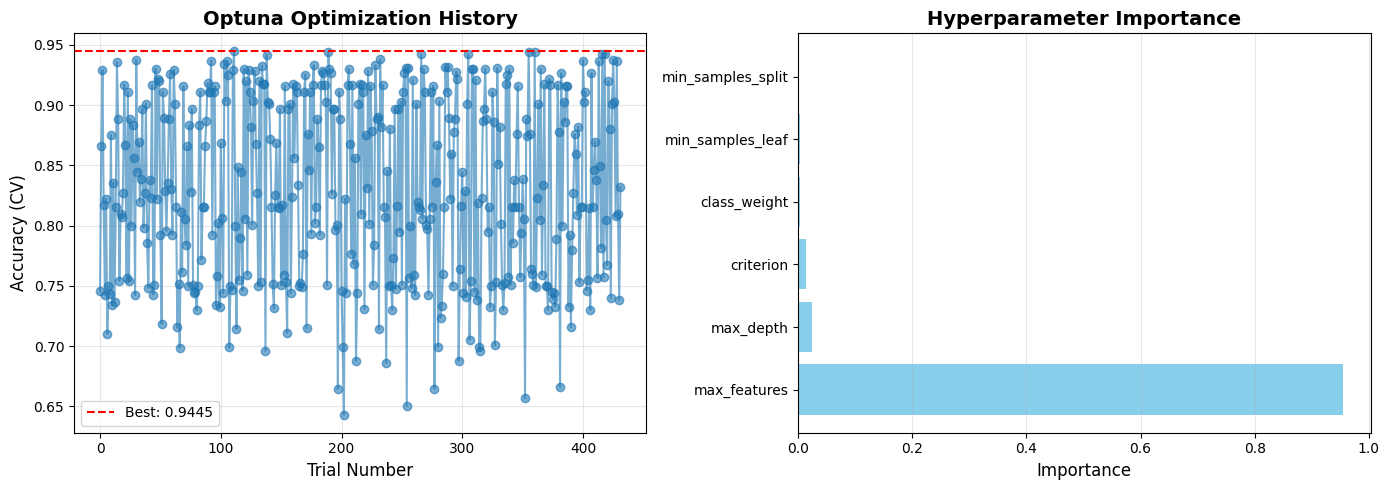


✓ Completed 432 trials
✓ Best trial achieved 94.45% accuracy


In [26]:
# Visualize optimization history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Optimization history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], marker='o', linestyle='-', alpha=0.6)
axes[0].axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial Number', fontsize=12)
axes[0].set_ylabel('Accuracy (CV)', fontsize=12)
axes[0].set_title('Optuna Optimization History', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Parameter importance
try:
    param_importance = optuna.importance.get_param_importances(study)
    params = list(param_importance.keys())
    importances = list(param_importance.values())
    
    axes[1].barh(params, importances, color='skyblue')
    axes[1].set_xlabel('Importance', fontsize=12)
    axes[1].set_title('Hyperparameter Importance', fontsize=14, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='x')
except:
    axes[1].text(0.5, 0.5, 'Not enough trials\nfor importance analysis', 
                 ha='center', va='center', fontsize=12)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✓ Completed {len(study.trials)} trials")
print(f"✓ Best trial achieved {100 * study.best_value:.2f}% accuracy")

In [27]:
# # Extract best parameters from the study
# best_params = study.best_params
# print("Best parameters extracted from study:")
# for key, value in best_params.items():
#     print(f"  {key}: {value}")

# # Save the best parameters and model for future use
# import pickle
# from datetime import datetime

# timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# # Save best parameters
# params_filename = f'../saved_models/DecisionTree_BestParams_{timestamp}.pkl'
# with open(params_filename, 'wb') as f:
#     pickle.dump(best_params, f)
# print(f"\n✓ Best parameters saved to: {params_filename}")

# # Save the trained model
# model_filename = f'../saved_models/DecisionTree_model_{timestamp}.pkl'
# with open(model_filename, 'wb') as f:
#     pickle.dump(pipe, f)
# print(f"✓ Trained model saved to: {model_filename}")

In [28]:
# Train final model with best parameters
best_params_with_prefix = {f'DT__{key}': value for key, value in study.best_params.items()}

pipe.set_params(**best_params_with_prefix)

# Fit the model
print("Training final model with best parameters...")
print("Best parameters being used:")
for key, value in best_params_with_prefix.items():
    print(f"  {key}: {value}")

pipe.fit(x_train, y_train)
print("\n✓ Model training completed!")

print("\nFinal pipeline steps:")
for step_name, step in pipe.steps:
    print(f"  {step_name}: {step.__class__.__name__}")

Training final model with best parameters...
Best parameters being used:
  DT__criterion: gini
  DT__max_depth: 15
  DT__min_samples_leaf: 15
  DT__min_samples_split: 20
  DT__max_features: None
  DT__class_weight: None

✓ Model training completed!

Final pipeline steps:
  Preprocessor: ColumnTransformer
  DT: DecisionTreeClassifier

✓ Model training completed!

Final pipeline steps:
  Preprocessor: ColumnTransformer
  DT: DecisionTreeClassifier


## Train the Model

In [29]:
# Train the pipeline
print("Training Decision Tree model with optimized hyperparameters...")
pipe.fit(x_train, y_train)
print("✓ Model training completed!")

Training Decision Tree model with optimized hyperparameters...
✓ Model training completed!
✓ Model training completed!


## Evaluate Model Performance

In [30]:
# Make predictions and evaluate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = pipe.predict(x_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*60)
print("Test Set Performance")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({100 * accuracy:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("="*60)

Test Set Performance
Accuracy:  0.9488 (94.88%)
Precision: 0.7666
Recall:    0.9096
F1 Score:  0.8320


In [31]:
# Classification Report
from sklearn.metrics import classification_report

print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Delayed', 'Delayed']))

Classification Report:
              precision    recall  f1-score   support

 Not Delayed       0.98      0.96      0.97      7440
     Delayed       0.77      0.91      0.83      1206

    accuracy                           0.95      8646
   macro avg       0.88      0.93      0.90      8646
weighted avg       0.95      0.95      0.95      8646



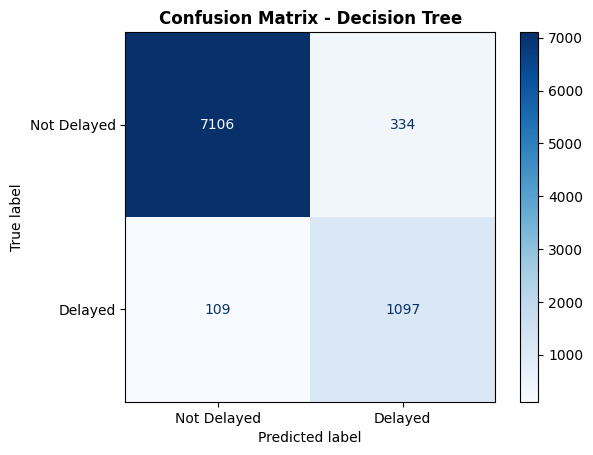


Specificity (True Negative Rate): 0.9551 (95.51%)
Sensitivity (True Positive Rate/Recall): 0.9096 (90.96%)


In [32]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Delayed', 'Delayed'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Decision Tree', fontweight='bold')
plt.show()

# Calculate Specificity and Sensitivity
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

print(f'\nSpecificity (True Negative Rate): {specificity:.4f} ({100 * specificity:.2f}%)')
print(f'Sensitivity (True Positive Rate/Recall): {sensitivity:.4f} ({100 * sensitivity:.2f}%)')

ROC AUC Score: 0.9797 (97.97%)


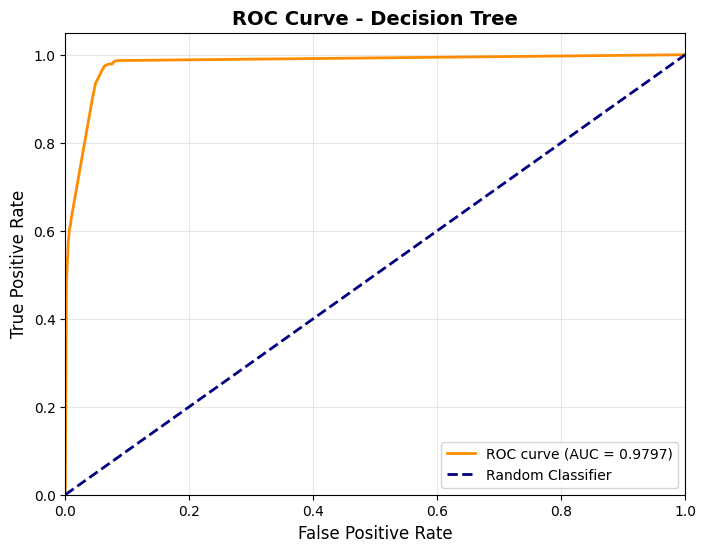

In [33]:
# ROC AUC Score and Curve
from sklearn.metrics import roc_auc_score, roc_curve

# Get prediction probabilities for ROC curve
y_pred_proba = pipe.predict_proba(x_test)[:, 1]

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC AUC Score: {roc_auc:.4f} ({100 * roc_auc:.2f}%)')

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Decision Tree', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [34]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28818 entries, 0 to 28819
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MONTH              28818 non-null  int64  
 1   DAY_OF_MONTH       28818 non-null  int64  
 2   DAY_OF_WEEK        28818 non-null  int64  
 3   OP_UNIQUE_CARRIER  28818 non-null  object 
 4   DEST               28818 non-null  object 
 5   CRS_ELAPSED_TIME   28818 non-null  int64  
 6   DISTANCE           28818 non-null  int64  
 7   CRS_DEP_M          28818 non-null  int64  
 8   DEP_TIME_M         28818 non-null  int64  
 9   CRS_ARR_M          28818 non-null  int64  
 10  Temperature        28818 non-null  int64  
 11  Dew Point          28818 non-null  object 
 12  Humidity           28818 non-null  int64  
 13  Wind               28818 non-null  object 
 14  Wind Speed         28818 non-null  int64  
 15  Wind Gust          28818 non-null  int64  
 16  Pressure           28818 no